In [3]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

REPO_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'preprocess' else Path.cwd().resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from preprocess.convert_raw_pkl_to_flower import (
    build_rel_action,
    load_episode_records,
    parse_slice,
    select_action_vector,
)
plt.style.use('default')

#plt.style.use('seaborn-v0_8')

In [6]:
# Edit these values for your dataset.
INPUT_PATH = Path("/data2/jack/multi_usb_p2")
PKL_GLOB = "**/*.pkl"
STATE_KEY = 'state'
ACTION_SLICE = '7:14'
STATE_POSE_SLICE = '23:29'
PREFER_INTERVENE_ACTION = False
MAX_STEPS = 3000  # set an int for a faster preview

action_slice = parse_slice(ACTION_SLICE)
pose_slice = parse_slice(STATE_POSE_SLICE)

print(f'INPUT_PATH={INPUT_PATH}')
print(f'ACTION_SLICE={ACTION_SLICE}, STATE_POSE_SLICE={STATE_POSE_SLICE}')

INPUT_PATH=/data2/jack/multi_usb_p2
ACTION_SLICE=7:14, STATE_POSE_SLICE=23:29


In [7]:
records = load_episode_records(INPUT_PATH, PKL_GLOB)
episode_lengths = np.array([len(record.steps) for record in records], dtype=np.int32)

print(f'Loaded {len(records)} episodes')
print(f'Total steps: {episode_lengths.sum()}')
print(f'Episode length min/median/max: {episode_lengths.min()} / {np.median(episode_lengths)} / {episode_lengths.max()}')

Loading pickle files: 100%|██████████| 10/10 [00:40<00:00,  4.01s/it]

Loaded 100 episodes
Total steps: 18127
Episode length min/median/max: 122 / 176.5 / 292


In [8]:
raw_actions = []
state_delta_actions = []
metadata = []

for global_episode_idx, record in enumerate(records):
    for step_idx, step in enumerate(record.steps):
        raw_action = select_action_vector(step, action_slice, PREFER_INTERVENE_ACTION)
        delta_action = build_rel_action(
            step,
            action_source='state_delta',
            state_key=STATE_KEY,
            pose_slice=pose_slice,
            action_slice=action_slice,
            prefer_intervene_action=PREFER_INTERVENE_ACTION,
        )
        raw_actions.append(raw_action)
        state_delta_actions.append(delta_action)
        metadata.append({
            'global_episode_idx': global_episode_idx,
            'source_name': record.source_name,
            'source_episode_index': record.source_episode_index,
            'step_idx': step_idx,
        })
        if MAX_STEPS is not None and len(raw_actions) >= MAX_STEPS:
            break
    if MAX_STEPS is not None and len(raw_actions) >= MAX_STEPS:
        break

raw_actions = np.asarray(raw_actions, dtype=np.float32)
state_delta_actions = np.asarray(state_delta_actions, dtype=np.float32)
diff = raw_actions - state_delta_actions

print('raw_actions shape      :', raw_actions.shape)
print('state_delta shape     :', state_delta_actions.shape)
print('difference shape      :', diff.shape)

raw_actions shape      : (3000, 7)
state_delta shape     : (3000, 7)
difference shape      : (3000, 7)


In [9]:
DIM_NAMES = ['dx', 'dy', 'dz', 'droll', 'dpitch', 'dyaw', 'gripper']

def summarize(array: np.ndarray, name: str):
    print(f'\n[{name}]')
    for dim_idx, dim_name in enumerate(DIM_NAMES):
        column = array[:, dim_idx]
        print(
            f'{dim_name:>7s} | '
            f'mean={column.mean(): .6f} '
            f'std={column.std(): .6f} '
            f'min={column.min(): .6f} '
            f'max={column.max(): .6f} '
            f'p01={np.percentile(column, 1): .6f} '
            f'p99={np.percentile(column, 99): .6f}'
        )

summarize(raw_actions, 'raw')
summarize(state_delta_actions, 'state_delta')
summarize(diff, 'raw - state_delta')


[raw]
     dx | mean= 0.018335 std= 0.075697 min=-0.177891 max= 0.542882 p01=-0.079087 p99= 0.360123
     dy | mean= 0.010060 std= 0.094123 min=-0.441333 max= 0.457807 p01=-0.249226 p99= 0.337755
     dz | mean=-0.003407 std= 0.095857 min=-0.357910 max= 0.514332 p01=-0.179556 p99= 0.315803
  droll | mean=-0.004226 std= 0.044097 min=-0.336227 max= 0.150441 p01=-0.183310 p99= 0.099764
 dpitch | mean=-0.012045 std= 0.067354 min=-0.330291 max= 0.339226 p01=-0.189213 p99= 0.260082
   dyaw | mean=-0.011019 std= 0.021318 min=-0.129100 max= 0.059341 p01=-0.089109 p99= 0.013902
gripper | mean= 0.000091 std= 0.085515 min=-0.982807 max= 0.991513 p01= 0.000000 p99= 0.000000

[state_delta]
     dx | mean= 0.000287 std= 0.002894 min=-0.049952 max= 0.015491 p01=-0.001800 p99= 0.008248
     dy | mean= 0.000130 std= 0.002737 min=-0.028990 max= 0.038266 p01=-0.006791 p99= 0.008395
     dz | mean= 0.000054 std= 0.002590 min=-0.017764 max= 0.016629 p01=-0.005023 p99= 0.008486
  droll | mean=-0.000065 std

In [10]:
l2_error = np.linalg.norm(diff, axis=1)
linf_error = np.max(np.abs(diff), axis=1)

print('L2 error mean   :', float(l2_error.mean()))
print('L2 error median :', float(np.median(l2_error)))
print('L2 error p95    :', float(np.percentile(l2_error, 95)))
print('L_inf error mean:', float(linf_error.mean()))
print('L_inf error p95 :', float(np.percentile(linf_error, 95)))

L2 error mean   : 0.12373502552509308
L2 error median : 0.0875101312994957
L2 error p95    : 0.35683996081352193
L_inf error mean: 0.10634775459766388
L_inf error p95 : 0.312236849963665


In [11]:
top_k = 10
top_indices = np.argsort(l2_error)[-top_k:][::-1]

for rank, idx in enumerate(top_indices, start=1):
    meta = metadata[idx]
    print(f'Rank {rank}')
    print(
        f"  source={meta['source_name']} episode={meta['source_episode_index']} "
        f"global_episode={meta['global_episode_idx']} step={meta['step_idx']}"
    )
    print('  raw         =', np.array2string(raw_actions[idx], precision=6, suppress_small=False))
    print('  state_delta =', np.array2string(state_delta_actions[idx], precision=6, suppress_small=False))
    print('  diff        =', np.array2string(diff[idx], precision=6, suppress_small=False))
    print('  l2_error    =', float(l2_error[idx]))
    print()

Rank 1
  source=10_demos_2026-04-24_20-59-06 episode=4 global_episode=4 step=82
  raw         = [5.428816e-01 0.000000e+00 1.906419e-06 0.000000e+00 1.794545e-01
 0.000000e+00 0.000000e+00]
  state_delta = [ 3.376424e-03 -3.635287e-04 -2.353489e-04  2.622604e-06 -1.225471e-04
 -1.213551e-04  0.000000e+00]
  diff        = [ 5.395052e-01  3.635287e-04  2.372554e-04 -2.622604e-06  1.795771e-01
  1.213551e-04  0.000000e+00]
  l2_error    = 0.5686070322990417

Rank 2
  source=10_demos_2026-04-24_20-59-06 episode=4 global_episode=4 step=94
  raw         = [ 0.000913  0.412267  0.015313 -0.336227  0.004913  0.036111  0.      ]
  state_delta = [-4.825890e-04  7.495090e-03  3.412366e-06  2.310276e-04  1.566410e-03
  4.169941e-04  0.000000e+00]
  diff        = [ 0.001396  0.404772  0.015309 -0.336458  0.003346  0.035694  0.      ]
  l2_error    = 0.5277934670448303

Rank 3
  source=10_demos_2026-04-24_21-06-46 episode=1 global_episode=11 step=145
  raw         = [-4.887709e-03  1.544301e-05  5.1

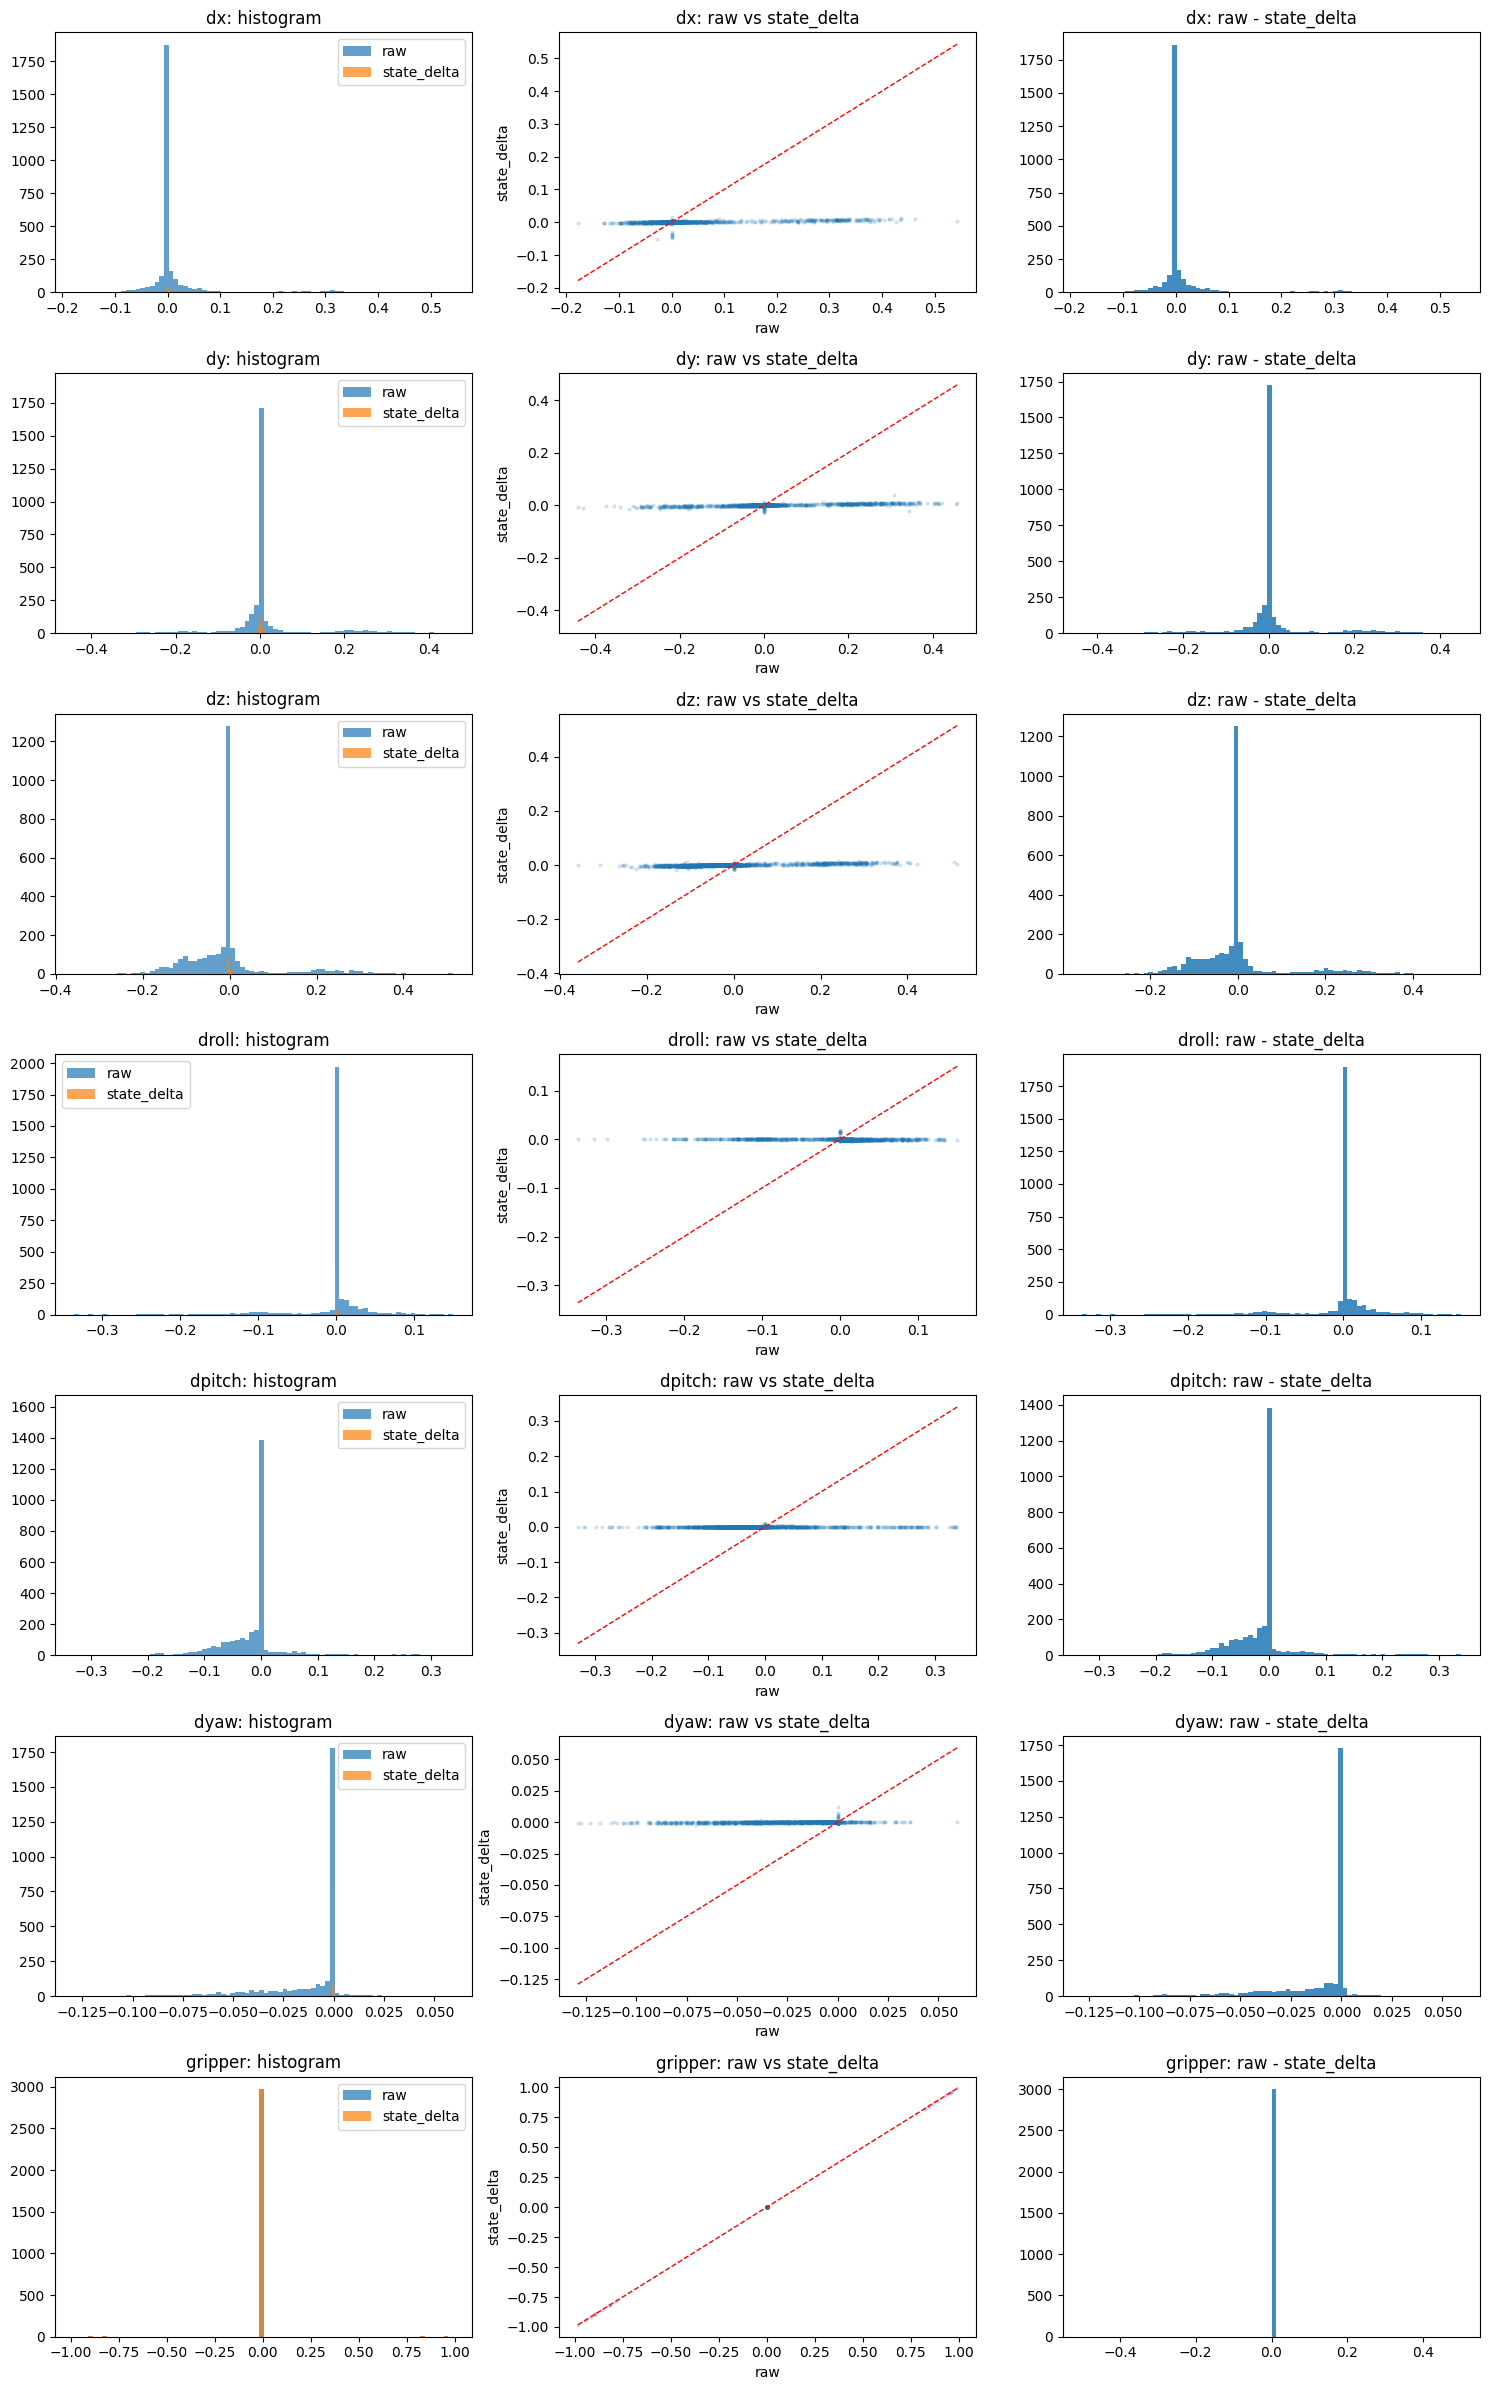

In [12]:
fig, axes = plt.subplots(7, 3, figsize=(15, 24))

for dim_idx, dim_name in enumerate(DIM_NAMES):
    raw_col = raw_actions[:, dim_idx]
    delta_col = state_delta_actions[:, dim_idx]
    diff_col = diff[:, dim_idx]

    axes[dim_idx, 0].hist(raw_col, bins=80, alpha=0.7, label='raw')
    axes[dim_idx, 0].hist(delta_col, bins=80, alpha=0.7, label='state_delta')
    axes[dim_idx, 0].set_title(f'{dim_name}: histogram')
    axes[dim_idx, 0].legend()

    axes[dim_idx, 1].scatter(raw_col, delta_col, s=4, alpha=0.15)
    lo = min(raw_col.min(), delta_col.min())
    hi = max(raw_col.max(), delta_col.max())
    axes[dim_idx, 1].plot([lo, hi], [lo, hi], 'r--', linewidth=1)
    axes[dim_idx, 1].set_title(f'{dim_name}: raw vs state_delta')
    axes[dim_idx, 1].set_xlabel('raw')
    axes[dim_idx, 1].set_ylabel('state_delta')

    axes[dim_idx, 2].hist(diff_col, bins=80, alpha=0.85)
    axes[dim_idx, 2].set_title(f'{dim_name}: raw - state_delta')

plt.tight_layout()
plt.show()

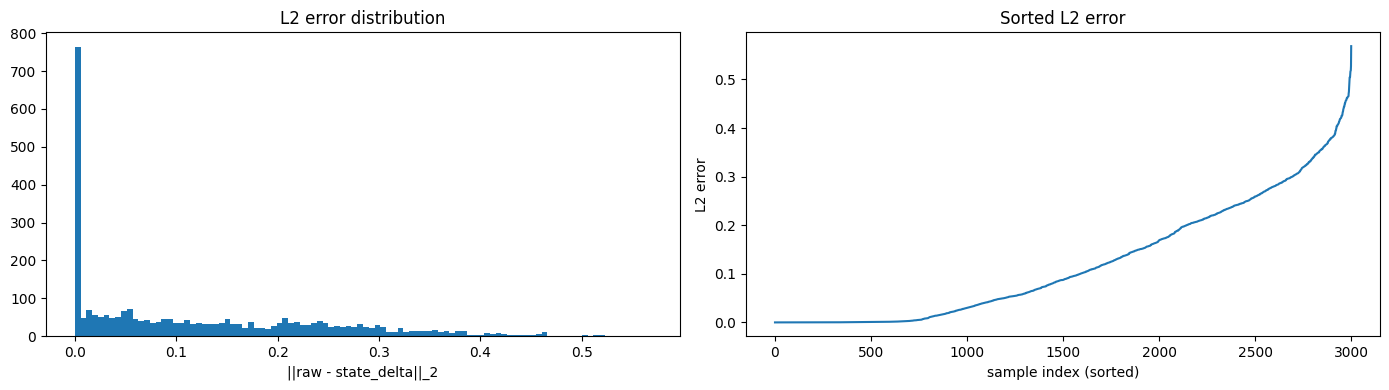

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(l2_error, bins=100)
axes[0].set_title('L2 error distribution')
axes[0].set_xlabel('||raw - state_delta||_2')

axes[1].plot(np.sort(l2_error))
axes[1].set_title('Sorted L2 error')
axes[1].set_xlabel('sample index (sorted)')
axes[1].set_ylabel('L2 error')

plt.tight_layout()
plt.show()